In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd

In [2]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

        #Wiener Process by default
        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1
        self.bxt_x = lambda x: 0
        self.bxt_xx = lambda x: 0
        self.sigmaxt_x = lambda x: 0
        self.sigmaxt_xx = lambda x: 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        result = np.zeros(self.Nx)
        for k in range(0, self.Nx):
            result[k] = x0[k] + np.random.normal(0, 1) * np.sqrt(t - t0)
        return result

    def PathGenerator(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = self.SampleFromDensity(x_data[i - 1], t_data[i], t_data[i - 1])
        return t_data, x_data

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + dwt[i - 1]
        return t_data, x_data

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data

    def Milstein1Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + \
                        1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * (dwt[i - 1]**2 - dt)
        return t_data, x_data

    def Milstein2Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1]) - 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])) * dt +\
                        self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) + 1/2 * self.bxt_x(x_data[i - 1]) * self.sigmaxt(x_data[i - 1]) +\
                        1/4 * self.sigmaxt(x_data[i - 1])**2 * self.sigmaxt_xx(x_data[i - 1])) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.bxt_x(x_data[i - 1]) + 1/4 * self.bxt_xx(x_data[i - 1]) * self.sigmaxt(x_data[i - 1])**2) * dt**2
        return t_data, x_data

    def PredictorCorrectorSolution(self, dwt, eta = 1/2, alpha = 1/2):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            yw = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
            bwim1 = self.bxt(x_data[i - 1]) - eta * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])
            bwi = self.bxt(yw) - eta * self.sigmaxt(yw) * self.sigmaxt_x(yw)
            x_data[i] = x_data[i - 1] + alpha * bwi * dt + (1 - alpha) * bwim1 * dt +\
                        eta * self.sigmaxt(yw) * dwt[i - 1] + (1 - eta) * self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]
        self.bxt_x = lambda x: -self.params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu
            v = sigma**2 / (2 * theta)
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu + (x0[j] - mu) * np.exp(-theta * (t - t0))
            v = sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t - t0)))
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = mu + (x_data[0] - mu) * np.exp(-theta * t_data)
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += sigma * np.exp(theta * t_data[i - 1]) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta * t_data[i])
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2, theta3]
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))
        self.bxt_x = lambda x: - self.params[1]
        self.sigmaxt_x = lambda x: self.params[2] * 1 / (2 * np.sqrt(np.maximum(x, 0)))
        self.sigmaxt_xx = lambda x: -self.params[2] * 1 / (4 * np.maximum(x, 0)**(1/4))

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2)
            u = 0
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
            u = c * x0[j] * np.exp(-k * (t - t0))
            #v = c * x
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data) + theta1/theta2
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += theta3 * np.exp(theta2 * t_data[i - 1]) * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta2 * t_data[i])
        return t_data, x_data


class BSMprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2] or [r, sigma]
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x
        self.bxt_x = lambda x: self.params[0]
        self.sigmaxt_x = lambda x: self.params[1]

    def DefaultInitState(self):
        return np.ones(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        r = self.params[0]
        sigma = self.params[1]

        result = np.zeros(self.Nx)

        m = (r - 1/2 * sigma**2) * (t - t0)
        v = sigma**2 * (t - t0)

        for j in range(0, self.Nx):
            result[j] = x0[j] * np.random.lognormal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        r = self.params[0]
        sigma = self.params[1]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * dwt[i - 1])
        return t_data, x_data

Еxercise  1. Suppose we have a   Brownian motion  defined by
 $$
 dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \text{ with } (\theta_1, \theta_2) = (2, 0.5).
 $$
Compare approximations
*   the Euler approximation algorithm;
*   the 1st Milstein scheme;
*   the 2nd Milstein scheme;
*   the predictor-corrector method  (set default $\alpha = \eta = 1/2$);
*   KPS method

with the exact solution on $[0,1]$, levels of discretization $N=1024$.


Упражнение 1. Предположим, что броуновское движение задано:
$$
dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \quad (\theta_1, \theta_2) = (2, 0.5).
$$
Сравните численные схемы
* алгоритм приближения Эйлера;
* 1-я схема Мильштейна;
* 2-я схема Мильштейна;
* метод предиктора-корректора (по умолчанию $\alpha = \eta = 1/2$);
* метод KPS

с точным решением на интервале $[0,1]$, для $N=1024$ точек.

In [3]:
T = 1
Nx = 1
Nt = 1024

x0 = 1
init_state = x0 * np.ones(Nx)

#theta = 2
#mu = 10
#sigma = 3.5
#params = [theta, mu, sigma]

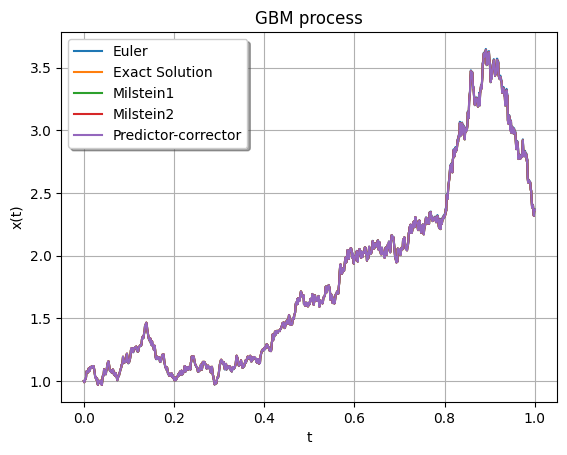

In [4]:
theta1 = 1
theta2 = 1/2
params = [theta1, theta2]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)


BSMp = BSMprocess(params, T, Nx, Nt, init_state)
t_data, x_data = BSMp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = BSMp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = BSMp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = BSMp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = BSMp.PredictorCorrectorSolution(dwt, 1/2, 1/2)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("GBM process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the different approximations and the exact solution Brownian motion
for different levels of discretization
$$
N=\{2, 4, 8, 128, 256, 512, 1024, 8192, 16384, 32768\}
$$
being the number of subintervals of $[0,1]$.
As the result provide the table with maximum absolute difference.


In [5]:
# your code

Task. Conduct a study of the influence of the choice of values $\alpha$ and $\eta$ ​​on the accuracy of the  solution and plot a 3D graph where the x-axis is $α$'s values, y-axis is $\eta$'s values, and z-axis are maximum absolute difference between the exact solution and the predictor-corrector approximation.



In [6]:
# your code

Task 2.  Repeat the Task 1 for the Cox-Ingersoll-Ross process
$$
dX_t = (\theta_1 - \theta_2X_t)dt + \theta_3 \sqrt{ X_t}dW_t, X_0 = 10, (\theta_1, \theta_2, \theta_3) = (6, 3, 2).
$$

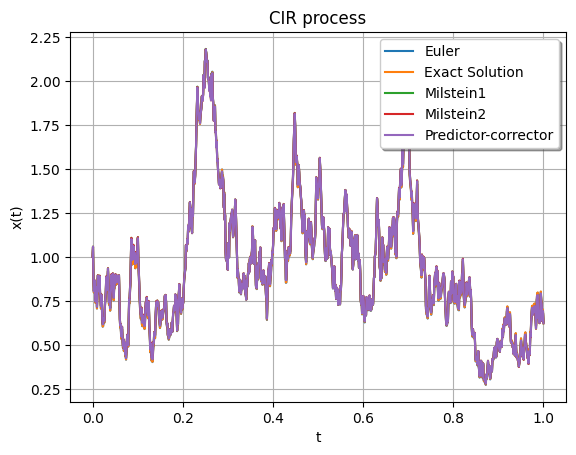

In [7]:
theta1 = 6
theta2 = 3
theta3 = 2
params = [theta1, theta2, theta3]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)

CIRp = CIRprocess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = CIRp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = CIRp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = CIRp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = CIRp.PredictorCorrectorSolution(dwt, 0.4, 0.6)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("CIR process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the speed of convergence for four schemes from Task 1 with extract solution on the graph where the x-axis is  log(N) values, y-axis is  X(t). See example in the study aid.

In [ ]:
# your code

Task 3. Generate 100 paths using conditional distribution of
* Ornstein-Uhlenbeck process $θ = (1, 1, 0.5)$,
* Geometric Brownian motion process $θ = (0.3, 0.1)$,
* Cox-Ingersoll-Ross process $θ = (0.4, 0.3, 0.2)$

with $X_0=0.5$.
Plot the random path for each process.

In [ ]:
Nx = 1
Nt = 300

T = 1

params_BSM = [1.0, 2.0]
params_CIR = [0.5, 0.2, 1.0]
params_OU  = [1.0, 0.5, 1.5]

init_state = 0.5 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)
BSMp = BSMprocess(params_BSM, T, Nx, Nt, init_state)
CIRp = CIRprocess(params_CIR, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.PathGenerator()
t_data, x_data_BSM = BSMp.PathGenerator()
t_data, x_data_CIR = CIRp.PathGenerator()

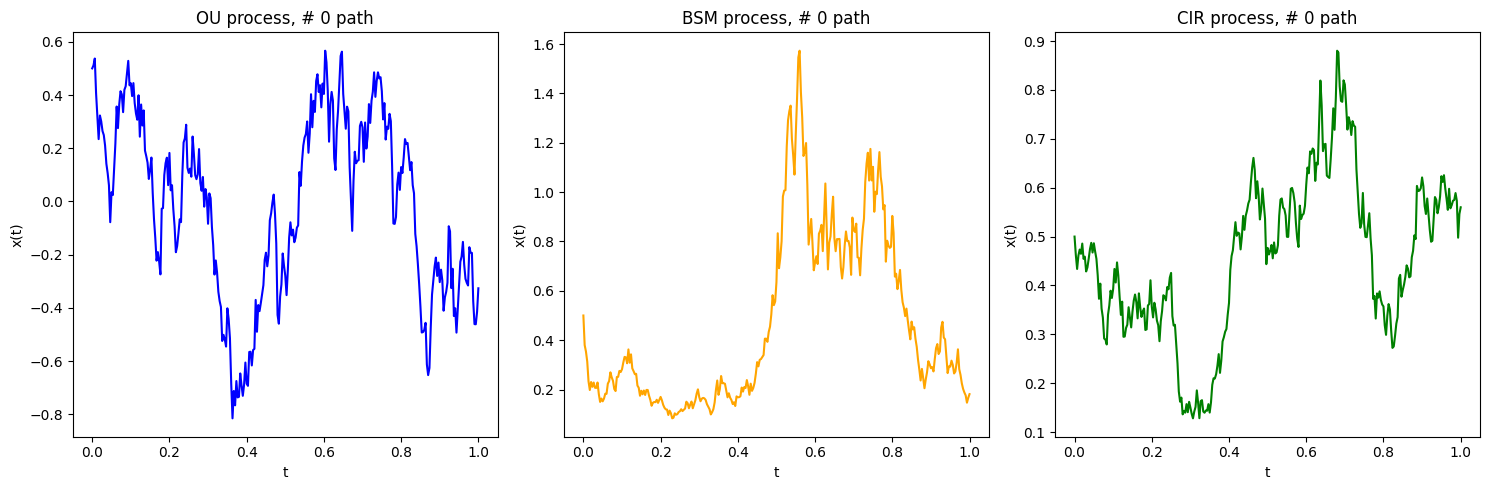

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

n = np.random.randint(0, Nx)

axs[0].plot(t_data, x_data_OU[:,n], color='blue')
axs[0].set_title(f'OU process, # {n} path')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x(t)')

axs[1].plot(t_data, x_data_BSM[:,n], color='orange')
axs[1].set_title(f'BSM process, # {n} path')
axs[1].set_xlabel('t')
axs[1].set_ylabel('x(t)')

axs[2].plot(t_data, x_data_CIR[:,n], color='green')
axs[2].set_title(f'CIR process, # {n} path')
axs[2].set_xlabel('t')
axs[2].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

In [ ]:
# save 100 paths to files

pd.DataFrame(data = x_data_OU, index = t_data).to_csv("OUprocess.csv")

pd.DataFrame(data = x_data_BSM, index = t_data).to_csv("BSMprocess.csv")

pd.DataFrame(data = x_data_CIR, index = t_data).to_csv("CIRprocess.csv")

Task. Using the class template from Task 1, create class and design the path generator for one from the following processes:

1.   Modified CIR model;
2.   Chan-Karolyi-Longstaff-Sanders family of models;
1.   Nonlinear mean reversion Ait-Sahalia model;
2.   Jacobi diffusion process;
1.   Ahn and Gao (inverse of Feller’s square root) model;
2.   Radial Ornstein-Uhlenbeck process.

In [ ]:
# your code

Task 4. For the processes from previous task plot
* cumulative distribution (cdf),
* density function (pdf),      
* calculate the 90\%-quantile.

In [ ]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(len(x))/float(len(x))
    return x, y

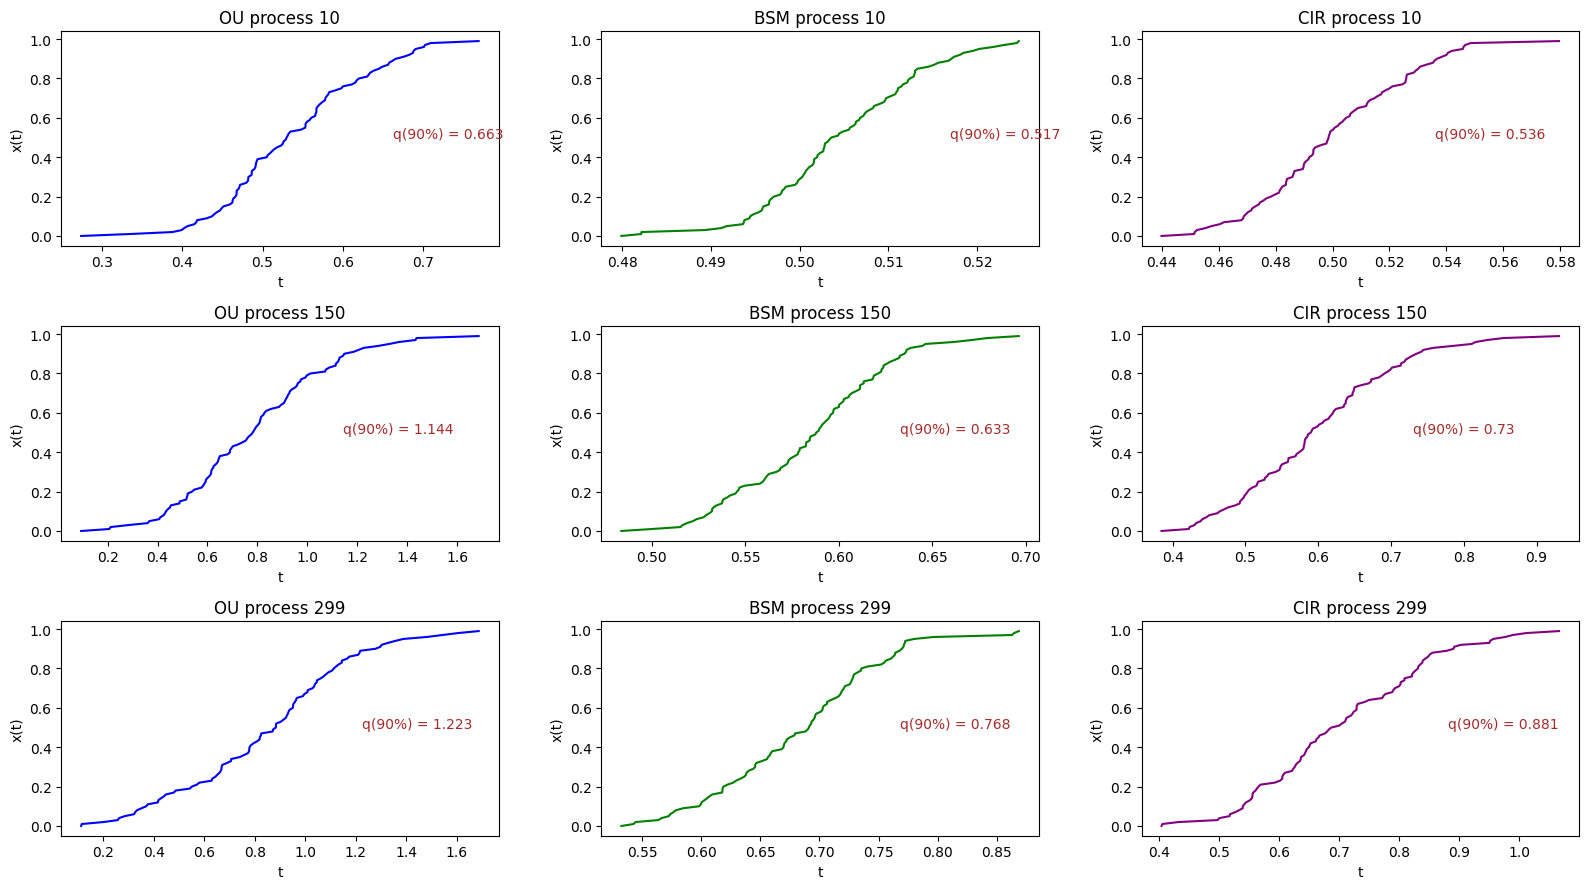

In [ ]:
#cdf function and 90% quantile

#distributions become more widely and change with time

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[0][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[1][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[2][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 3):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()
plt.show()

Task. Perform the Kolmogorov-Smirnov test for two samples and present your conclusions. Add vertical lines (90\%-quantile) into plots.
Resize the range on the X-axis so that all curves for one process have the same range.    

In [ ]:
# your code

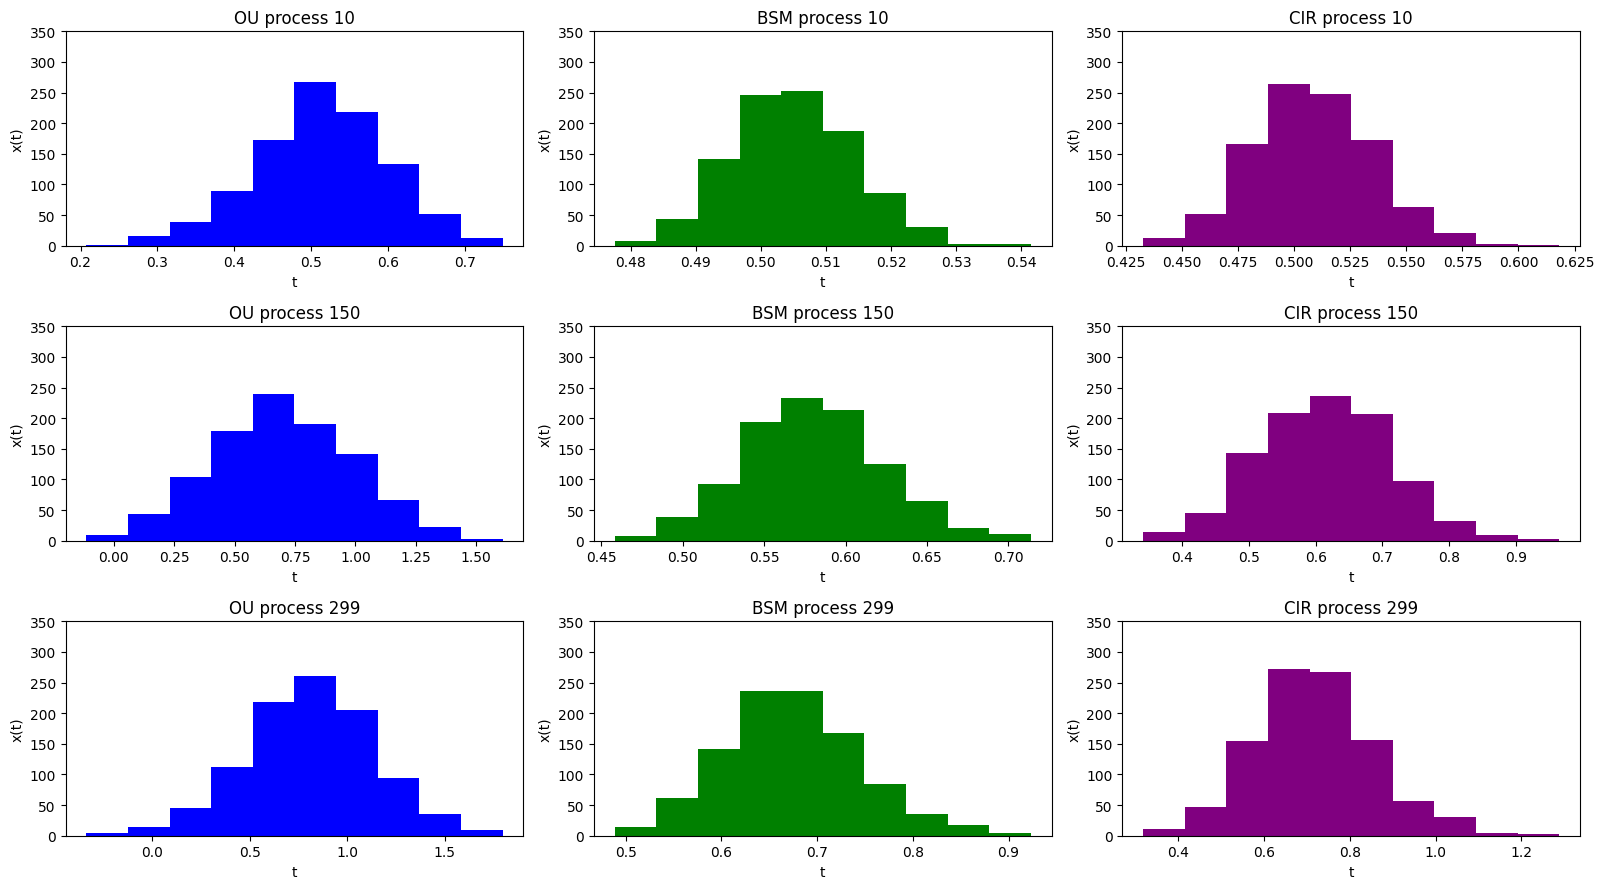

In [ ]:
#density function

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_BSM[n], color='green')
axs[0][1].set_title(f'BSM process {n}')

axs[0][2].hist(x_data_CIR[n], color='purple')
axs[0][2].set_title(f'CIR process {n}')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process {n}')

axs[1][1].hist(x_data_BSM[n], color='green')
axs[1][1].set_title(f'BSM process {n}')

axs[1][2].hist(x_data_CIR[n], color='purple')
axs[1][2].set_title(f'CIR process {n}')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process {n}')

axs[2][1].hist(x_data_BSM[n], color='green')
axs[2][1].set_title(f'BSM process {n}')

axs[2][2].hist(x_data_CIR[n], color='purple')
axs[2][2].set_title(f'CIR process {n}')

for k in range(0, 3):
    for j in range(0, 3):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

Task. Perform a normality test on the histograms and present your conclusions.

Task 5.

In [ ]:
#to get stationary state we set initial state to be stationary
#generate 1000 trajectories using conditional distribution
#BSM doesnt have stationary state

#Distribution properties do not change as expected for stationary state

Nx = 1000
Nt = 300

T = 1

params_OU = [1, 1, 0.5]
paramsCIR = [0.4, 0.3, 0.2]


OUp = OUprocess(params_OU, T, Nx, Nt)
OUp.init_state = OUp.StationaryState()

CIRp = CIRprocess(params_OU, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()

t_data, x_data_OU = OUp.PathGenerator()

t_data, x_data_CIR = CIRp.PathGenerator()

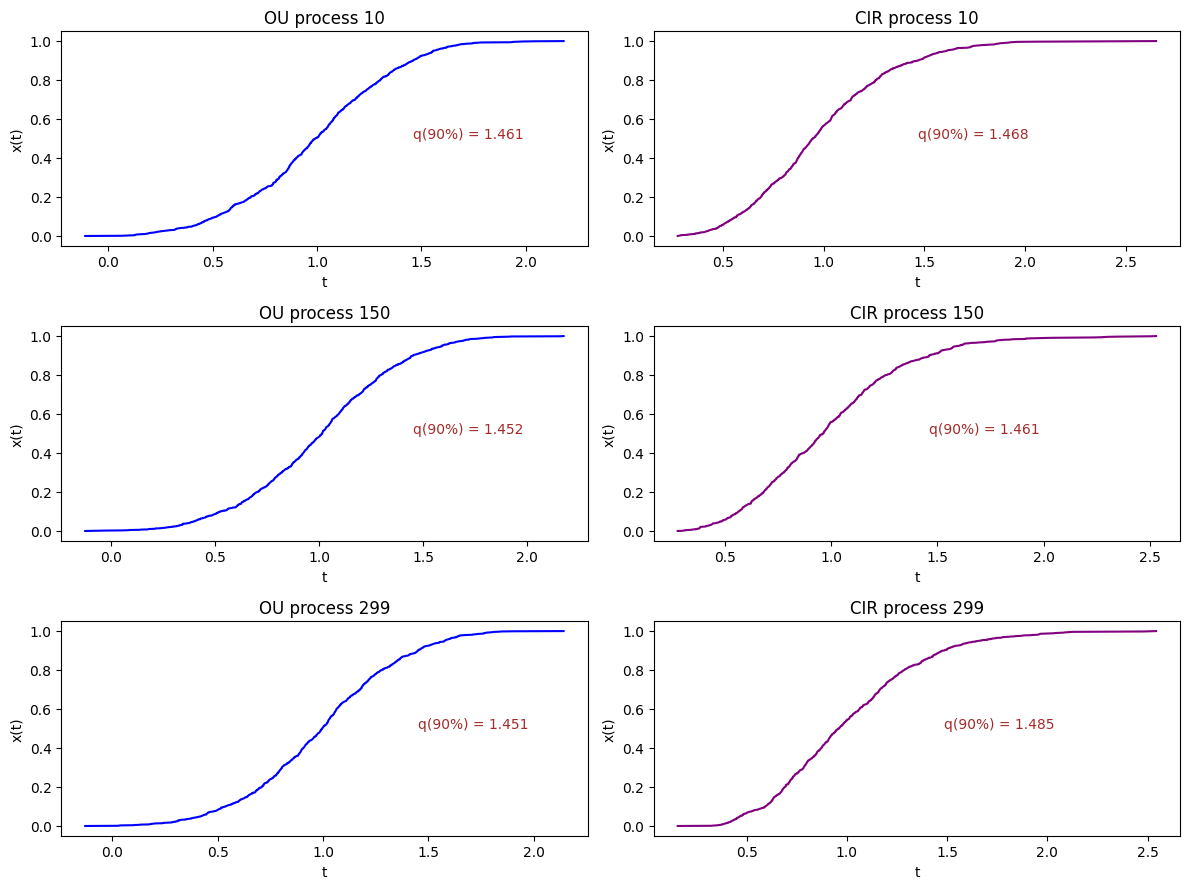

In [ ]:
#cdf function and 90% quantile

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 2):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

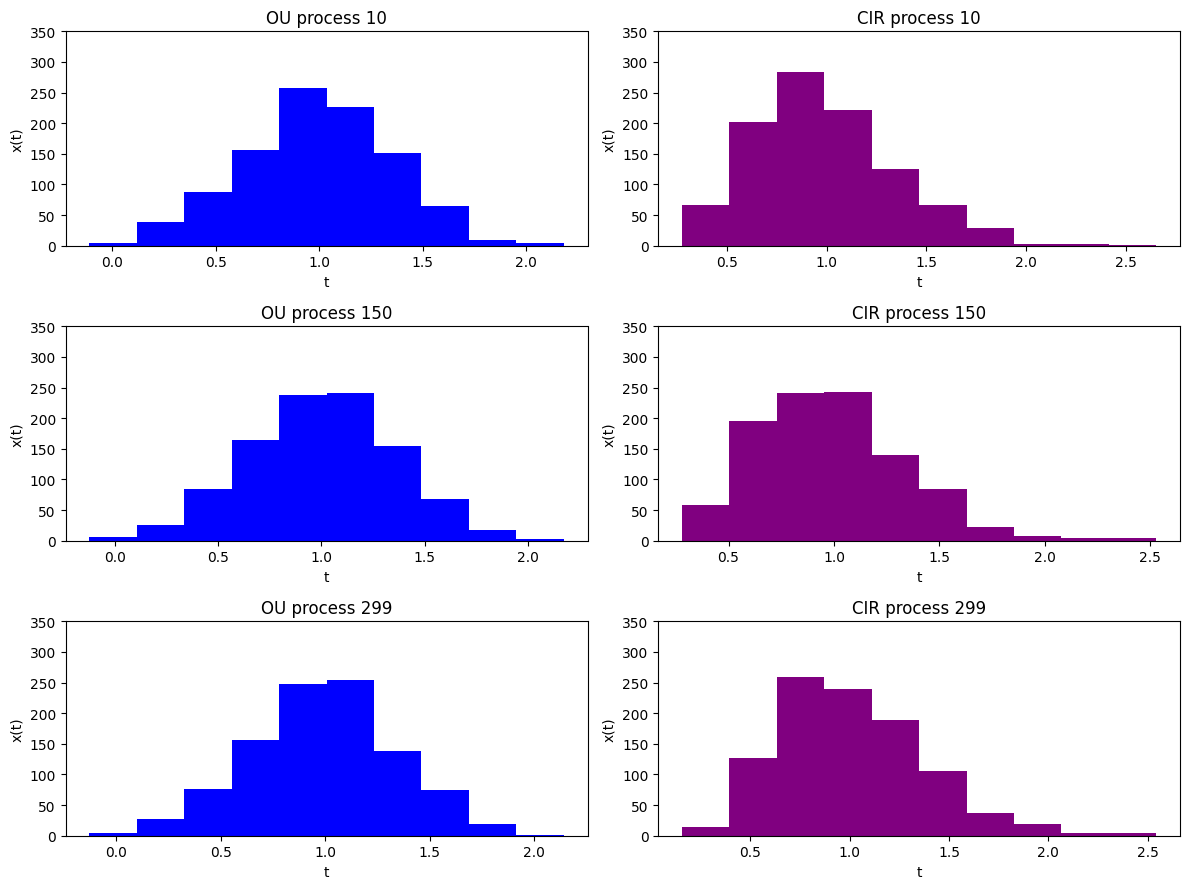

In [ ]:
#density function

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_CIR[n], color='purple')
axs[0][1].set_title(f'CIR process, # {n} path')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process, # {n} path')

axs[1][1].hist(x_data_CIR[n], color='purple')
axs[1][1].set_title(f'CIR process, # {n} path')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process, # {n} path')

axs[2][1].hist(x_data_CIR[n], color='purple')
axs[2][1].set_title(f'CIR process, # {n} path')

for k in range(0, 3):
    for j in range(0, 2):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

# Задачи

Задача 1. Сравнительный анализ численных схем

1. Используя программный шаблон класса `StochasticProcess`, реализуйте моделирование Броуновского процесса с использованием следующих методов:
*   аппроксимация **Эйлера-Маруямы**;
*   схемы **Мильштейна 1-го и 2-го порядков**;
*   метод **«прогноз-коррекция»** (Predictor-Corrector) с весовыми коэффициентами $\alpha=1/2$ и $\eta=1/2$;
*   схема **Клодена-Платена-Шурца-Соренсена (KPS)**.

2. Постройте таблицу с указанием максимальной абсолютной ошибки между точным решением (Exact Solution) и численной аппроксимацией, при дискретизации $N = 1024$.

3. Сделайте выводы.



***

Для исследования броуновского процесса берем уже написанный класс BSM (геометрическое броуновское движение) с разными аппроксимациями, и дополнительно напишем схему Клодена–Платена–Шурца–Соренсена (KPS)

In [ ]:
np.random.seed(42)

def KPSSolution(proc, dwt):
    """
        proc - process (variable type of StochasticProcess)
        dwt - dW_t
    """

    dt = proc.T / proc.Nt
    t_data = np.linspace(0, proc.T, proc.Nt + 1)
    x_data = np.zeros((proc.Nt + 1, proc.Nx))

    if proc.init_state is None:
        x_data[0] = proc.DefaultInitState()
    else:
        x_data[0] = proc.init_state

    # additional gaussian random variable dU_t
    #       dU_t = a*dW_t + b
    #   where a = cov(W,U) / var(W) = dt / 2
    #         var(b) = var(U) - (dt/2)^2 * var(W) = dt^3 / 12
    #         hence: b = sqrt(dt^3 / 12) * Z, where Z ~ N(0, 1)
    z = np.random.normal(0, 1, size=(proc.Nt, proc.Nx))
    dut = 0.5 * dt * dwt + np.sqrt(dt**3 / 12) * z

    for i in range(1, proc.Nt + 1):
        xi = x_data[i - 1]
        dw = dwt[i - 1]
        du = dut[i - 1]

        b = proc.bxt(xi)
        s = proc.sigmaxt(xi)
        bx = proc.bxt_x(xi)
        bxx = proc.bxt_xx(xi)
        sx = proc.sigmaxt_x(xi)
        sxx = proc.sigmaxt_xx(xi)

        # derivative (sigma * sigma_x)_x = sigma_x^2 + sigma * sigma_xx
        ssx_x = sx**2 + s * sxx

        x_data[i] = (
            xi
            + b * dt
            + s * dw
            + 0.5 * s * sx * (dw**2 - dt)
            + s * bx * du
            + 0.5 * (b * bx + 0.5 * s**2 * bxx) * dt**2
            + (b * sx + 0.5 * s**2 * sxx) * (dw * dt - du)
            + 0.5 * s * ssx_x * ((dw**2) / 3.0 - dt) * dw
        )

    return t_data, x_data

In [15]:
T = 1
Nx = 1
Nt = 1024

params = [2.0, 0.5]     # [r, sigma]
initial_state = np.ones(Nx)

dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(T / Nt)
process = BSMprocess(params, T, Nx, Nt, initial_state)

_, exact_path = process.ExactSolution(dwt)
approximations = [
    ("Euler-Maruyama", process.EulerSolution(dwt)[1]),
    ("Milstein 1", process.Milstein1Solution(dwt)[1]),
    ("Milstein 2", process.Milstein2Solution(dwt)[1]),
    ("Predictor-Corrector", process.PredictorCorrectorSolution(dwt, 0.5, 0.5)[1]),
    ("KPS", KPSSolution(process, dwt)[1]),
]

rows = []
for name, approx_path in approximations:
    max_error = np.max(np.abs(approx_path[:, 0] - exact_path[:, 0]))
    rows.append([name, max_error])

error_table = pd.DataFrame(rows, columns=["method", "Max Absolute Error"])
error_table

,method,Max Absolute Error
0,Euler-Maruyama,0.022301
1,Milstein 1,0.012583
2,Milstein 2,0.000168
3,Predictor-Corrector,0.000789
4,KPS,0.000058


#### Выводы

- Учитывая дискретизация N = 1024 все схемы довольно точно аппроксимируют точное решение, однако самая грубая оценка у Эйлера
- Переход к 1 подходу Мильштейна понизил ошибку в 2 раза
- Все остальные методы (2 подход Мильштейна, предиктор-корректор, KPS) понизили ошибку на 2-3 порядка, учитывая более глубокую структуру аппроксимации процесса
- Лучший показатель у метода KPS (разложение Ито больше порядка среди остальных)

***

Задача 2. Исследование скорости сходимости

1. Проведите количественный анализ точности аппроксимаций.
Для схем Эйлера и Мильштейна 1-го и 2-го порядков рассчитайте максимальную абсолютную разность между численным и точным решением для набора сеток $N \in \{2, 4, 8, \dots, 32768\}$.

2. Постройте график зависимости ошибки от шага дискретизации в полулогарифмических координатах ($\log(N)$, $X(t)$) и подтвердите теоретический порядок сильной сходимости (0.5 для Эйлера, 1.0 для Мильштейна 1-го порядка, 2.0 для Мильштейна 2-го порядка).

3. Сделайте выводы.



In [ ]:
np.random.seed(42)

T = 1.0
Nx = 1

# params for BSM
params = [2.0, 0.5]     # [r, sigma]
initial_state = np.ones(Nx)

grid_sizes = [2**k for k in range(1, 18)]

rows = []

for Nt in grid_sizes:
    dt = T / Nt
    dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(dt)

    process = BSMprocess(params, T, Nx, Nt, initial_state)

    _, exact_path = process.ExactSolution(dwt)
    _, euler_path = process.EulerSolution(dwt)
    _, milstein1_path = process.Milstein1Solution(dwt)
    _, milstein2_path = process.Milstein2Solution(dwt)

    euler_err = np.max(np.abs(euler_path[:, 0] - exact_path[:, 0]))
    milstein1_err = np.max(np.abs(milstein1_path[:, 0] - exact_path[:, 0]))
    milstein2_err = np.max(np.abs(milstein2_path[:, 0] - exact_path[:, 0]))

    rows.append([Nt, dt, euler_err, milstein1_err, milstein2_err])

error_df = pd.DataFrame(
    rows,
    columns=["N", "h", "Euler", "Milstein 1", "Milstein 2"]
)

error_df.head()

,N,h,Euler,Milstein 1,Milstein 2
0,2,0.50000,1.615471,1.604794,0.372970
1,4,0.25000,1.404382,1.712134,0.094503
2,8,0.12500,4.116802,4.312322,0.353153
3,16,0.06250,1.022787,1.085108,0.041018
4,32,0.03125,0.698983,0.862168,0.006618


In [36]:
# empirical convergence rates
log_h = np.log(error_df["h"].values)

# fit log(error) = a + p * log(h)
euler_rate = np.polyfit(log_h, np.log(error_df["Euler"].values), 1)[0]
milstein1_rate = np.polyfit(log_h, np.log(error_df["Milstein 1"].values), 1)[0]
milstein2_rate = np.polyfit(log_h, np.log(error_df["Milstein 2"].values), 1)[0]

rate_table = pd.DataFrame({
    "method": ["Euler-Maruyama", "Milstein 1", "Milstein 2"],
    "empirical order": [euler_rate, milstein1_rate, milstein2_rate]
})

rate_table

,method,empirical order
0,Euler-Maruyama,0.665399
1,Milstein 1,1.041577
2,Milstein 2,1.140191


P.S. здесь считается максимальная траекторная ошибка, то есть сильная сходимость, которая у первых 2 методов около теории, а в случае Мильштейна 2 - не совпадает, так как 2 - это его порядок слабой сходимости

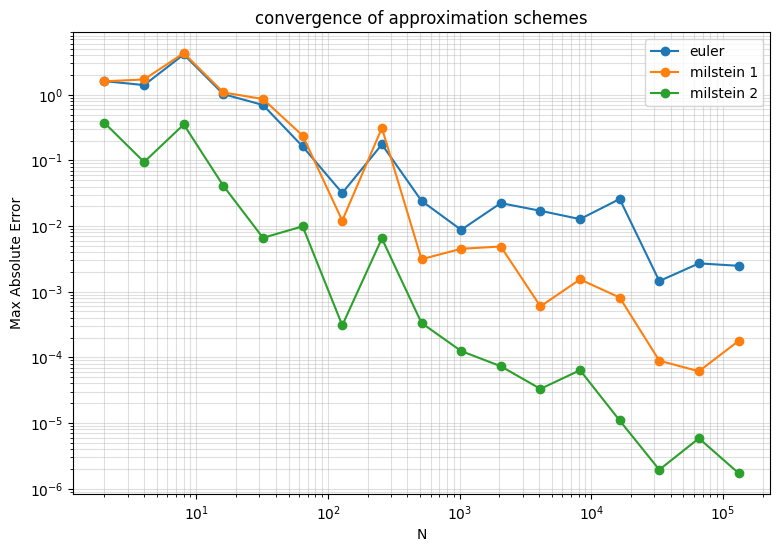

In [ ]:
plt.figure(figsize=(9, 6))

plt.loglog(error_df["N"], error_df["Euler"], marker="o", label="euler")
plt.loglog(error_df["N"], error_df["Milstein 1"], marker="o", label="milstein 1")
plt.loglog(error_df["N"], error_df["Milstein 2"], marker="o", label="milstein 2")

plt.xlabel("N")
plt.ylabel("Max Absolute Error")
plt.title("convergence of approximation schemes")
plt.grid(True, which="both", alpha=0.4)
plt.legend()
plt.show()

#### Выводы

- Все методы с ростом дискретизации лучше сходятся к точному решению, однако на графиках можно увидеть различие в порядке сходимости (разные наклоны), где у Эйлера самая медленная сходимость, а у Мильштейна 2 - самая быстрая
- Предсказанные скорости сходимости для Эйлера и Мильштейна 1 отражают теоретические порядки сильной сходимости (0.5 и 1), для Мильштейна 2 - порядок сходимости меньше теории, но это для сильной сходимости

***

Задача 3. Оптимизация метода «прогноз-коррекция»

Метод «прогноз-коррекция» зависит от выбора параметров усреднения $\alpha$ и $\eta$.

1. Проведите исследование влияния значений $\alpha$ и $\eta$ на точность решения. Модель стохастического процесса укажите самостоятельно.

2. Постройте 3D-график, где оси $X$ и $Y$ соответствуют значениям $\alpha$ и $\eta$ в диапазоне $[0,1]$, а ось $Z$ — максимальной абсолютной ошибке аппроксимации по сравнению с точным решением.

3. Сделайте выводы.



In [12]:
# Init BSM process and calculate exact path
T = 1.0
Nx = 1
Nt = 1024

params = [2.0, 0.5]
init_state = np.ones(Nx)

dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(T / Nt)

bsm = BSMprocess(params, T, Nx, Nt, init_state)
_, exact_path = bsm.ExactSolution(dwt)

In [13]:
# {alpha, eta} grid research
alpha_grid = np.linspace(0.0, 1.0, 25)
eta_grid = np.linspace(0.0, 1.0, 25)

error_surface = np.zeros((len(alpha_grid), len(eta_grid)))

for i, alpha in enumerate(alpha_grid):
    for j, eta in enumerate(eta_grid):
        _, approx_path = bsm.PredictorCorrectorSolution(dwt, eta=eta, alpha=alpha)
        error_surface[i, j] = np.max(np.abs(approx_path[:, 0] - exact_path[:, 0]))

# best hyperparam (alpha, eta)
best_index = np.unravel_index(np.argmin(error_surface), error_surface.shape)
best_alpha = alpha_grid[best_index[0]]
best_eta = eta_grid[best_index[1]]
best_error = error_surface[best_index]

print(f"best alpha = {best_alpha:.4f}")
print(f"best eta   = {best_eta:.4f}")
print(f"min error  = {best_error:.6e}")

best alpha = 0.5417
best eta   = 0.5000
min error  = 7.983643e-05


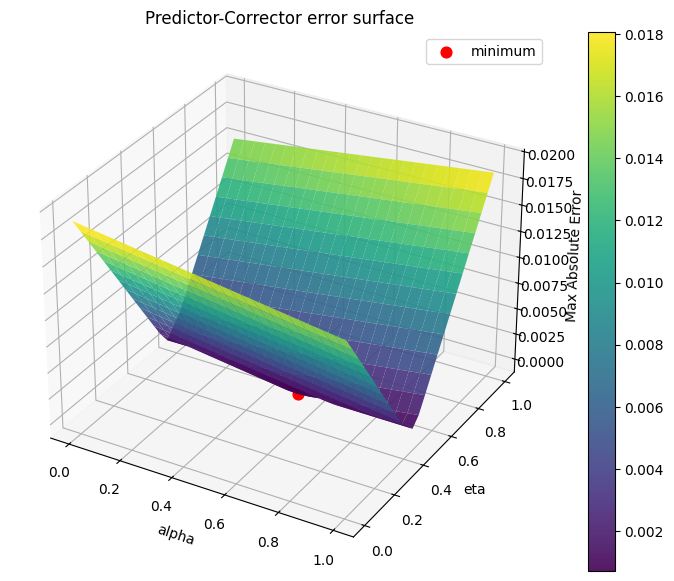

In [19]:
A, E = np.meshgrid(alpha_grid, eta_grid, indexing='ij')

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(A, E, error_surface, cmap="viridis", edgecolor="none", alpha=0.9)
ax.scatter(best_alpha, best_eta, best_error, color="red", s=60, label="minimum")

ax.set_title("Predictor-Corrector error surface")
ax.set_xlabel("alpha")
ax.set_ylabel("eta")
ax.set_zlabel('Max Absolute Error')
ax.legend()

fig.colorbar(surface, ax=ax)
plt.show()

#### Выводы

- Исследование показало, что точность метода сильно зависит от выбора параметров alpha и theta (ошибки изменяются на порядки), а лучшие значения находятся в окрестности точки (0.5, 0.5)
- На поверхности можно заметить симметричный минимум для параметра theta, то есть усреднения диффузионной части (откуда и минимум theta = 0.5)
- Оптимальный параметр alpha тоже находится в окрестности 0.5, но симметричность не такая ярко выраженная  

***

Задача 4. Моделирование экзотических процессов (из Раздела 8)

1. Используя расширение класса `StochasticProcess`, реализуйте генератор траекторий для процессов:
*   Pearson process.
*   Jacobi process.
*   Radial OU process.
*   Ahn and Gao model.

2. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: эмпирическая функция распределения (ecdf),  
     - Нижний график: гистограмма плотности (pdf)  
 для различных моментов времени $t=0.1$, $t=0.5$, $t=1.0$.

3. Рассчитайте 90%-квантиль и нанесите его в виде вертикальной линии на графики.

4. Сделайте выводы.

***

Генерировать траектории будем через метод Эйлера

In [ ]:
np.random.seed(42)

class PearsonProcess(StochasticProcess):
    # params = [kappa, theta, a0, a1, a2]
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: np.sqrt(np.maximum(
            self.params[2] + self.params[3] * x + self.params[4] * x**2,
            0.0
        ))


class JacobiProcess(StochasticProcess):
    # params = [kappa, theta, sigma]
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x * (1 - x), 0.0))


class RadialOUProcess(StochasticProcess):
    # params = [kappa, sigma]
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.bxt = lambda x: self.params[0] * (1.0 / x - x)
        self.sigmaxt = lambda x: self.params[1] * np.ones_like(x)


class AhnGaoProcess(StochasticProcess):
    # params = [a, b, sigma]
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] / x


def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

In [ ]:
Nx = 1000
Nt = 300
T = 1.0
dt = T / Nt

time_points = [0.1, 0.5, 1.0]
colors = ['tab:blue', 'tab:green', 'tab:red']

processes = [
    ("Pearson",   PearsonProcess([2.0, 0.5, 0.1, 0.0, 0.2], T, Nx, Nt, np.ones(Nx))),
    ("Jacobi",    JacobiProcess([2.0, 0.5, 0.3], T, Nx, Nt, 0.5 * np.ones(Nx))),
    ("Radial OU", RadialOUProcess([1.0, 0.5], T, Nx, Nt, np.ones(Nx))),
    ("Ahn-Gao",   AhnGaoProcess([1.0, 0.5, 0.3], T, Nx, Nt, np.ones(Nx))),
]

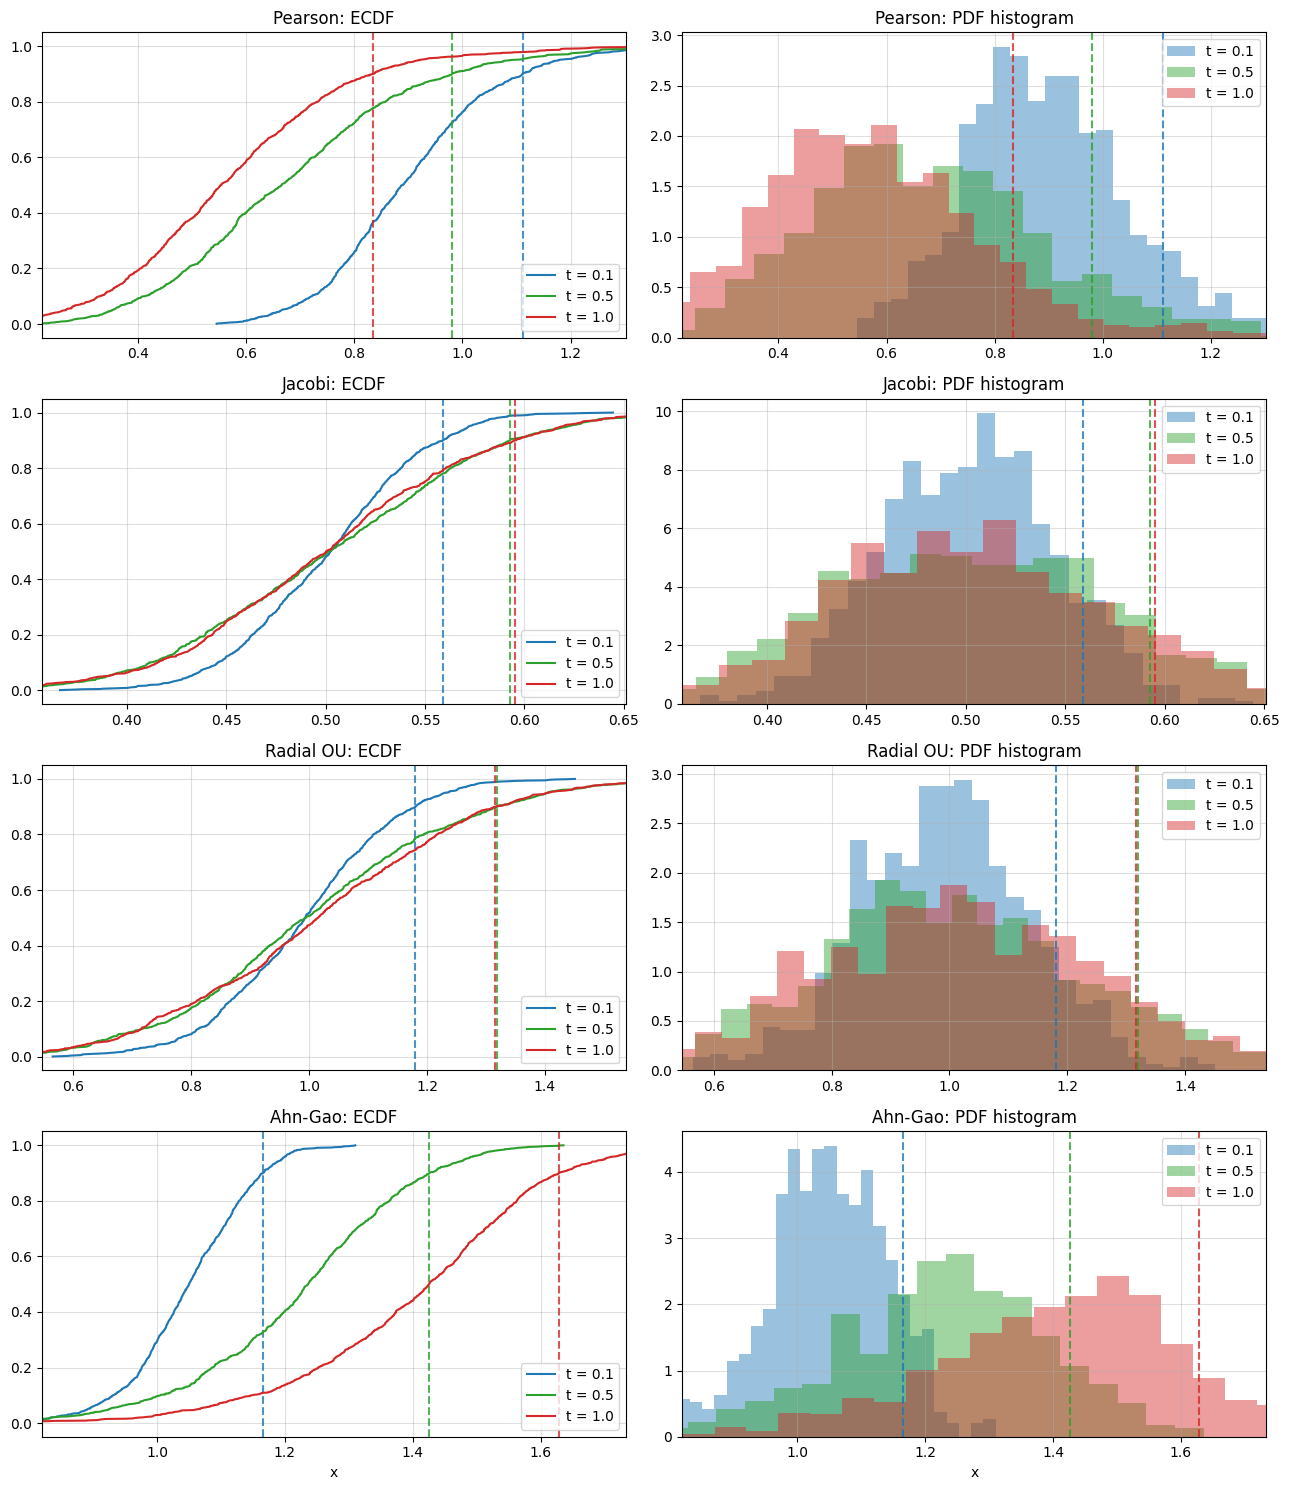

In [26]:
fig, axes = plt.subplots(len(processes), 2, figsize=(13, 15))

for row, (name, process) in enumerate(processes):
    dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(dt)
    t, x_data = process.EulerSolution(dwt)

    # use only selected times for x-limits
    selected_samples = []
    for tt in time_points:
        idx = int(tt / T * Nt)
        selected_samples.append(x_data[idx, :])

    all_selected = np.concatenate(selected_samples)
    x_min, x_max = np.percentile(all_selected, [1, 99])

    for color, tt in zip(colors, time_points):
        idx = int(tt / T * Nt)
        sample = x_data[idx, :]
        q90 = np.quantile(sample, 0.9)

        # ecdf + 90% quantile (dotted line)
        x_ecdf, y_ecdf = ecdf(sample)
        axes[row, 0].plot(x_ecdf, y_ecdf, color=color, label=f't = {tt}')
        axes[row, 0].axvline(q90, color=color, linestyle='--', alpha=0.8)

        # pdf histogram + 90% quantile (dotted line)
        axes[row, 1].hist(sample, bins=30, density=True, alpha=0.45, color=color, label=f't = {tt}')
        axes[row, 1].axvline(q90, color=color, linestyle='--', alpha=0.8)

    axes[row, 0].set_xlim(x_min, x_max)
    axes[row, 1].set_xlim(x_min, x_max)

    axes[row, 0].set_title(f'{name}: ECDF')
    axes[row, 1].set_title(f'{name}: PDF histogram')

    axes[row, 0].grid(True, alpha=0.4)
    axes[row, 1].grid(True, alpha=0.4)

    axes[row, 0].legend(loc='lower right')
    axes[row, 1].legend(loc='upper right')

axes[-1, 0].set_xlabel('x')
axes[-1, 1].set_xlabel('x')

plt.tight_layout()
plt.show()

#### Выводы

1) **Процесс Пирсона**: старт с 1, поэтому и гистограмма и функция распределения начинают справа и идут влево, дрейфуя к 0.5, что заметно и по квантилям и по общему сдвигу
2) **Процесс Якоби**: старт с 0.5, поэтому заметной эволюции процесса со временем нет, так как он колеблется около среднего theta = 0.5, причем без тяжелых хвостов из-за дрейфа, который мал у границ 0 и 1. Со временем шум немного "размазывает" распределение
3) **Радиальный процесс ОУ**: равновесная точка равна 1, откуда и старт, поэтому аналогично процессу якоби он колеблется около равновесного значения. Шум со временем "размазывает" распределение, увеличивая разброс
4) **Процесс Ahn-Gao**: равновесная точка равна 2, поэтому процесс, стартуя с 1, переезжает вправо (гистограмма и распределение) к большим значениям, мгновенная волатильность хотя падает (пропорциональна 1/x), но накапливается шум

***


Задача 5.
1. Сгенерируйте по 100 траекторий для процессов со следующими параметрами:  
   - OU: $θ = (1.0, 1.0, 0.5)$,  
   - CIR: $θ = (0.4, 0.3, 0.2)$,
   
   $X_0 = 0.5$, $T = 1$, $Nt = 300$, $Nx = 100$.

2. Для каждого процесса вычислите теоретическое стационарное распределение: OU (нормальное распределение), CIR (гамма-распределение) и постройте гистограммы значений процесса в момент $t = T$ (конечное состояние) для всех траекторий и наложите на них график теоретической плотности.

3. Для процессов вычислите условное среднее и дисперсию по теоретическим формулам: OU (условное распределение — нормальное), CIR условное распределение — нецентральное хи-квадрат.   

4. Постройте графики условного среднего $E[X_t | X_0]$ и условной дисперсии $Var[X_t | X_0]$ на интервале $[0, T]$.

5. Вычислите выборочное среднее и дисперсию по всем траекториям в моменты времени: $t = 0.1$, $t = 0.5$, $t = 1.0$. Сравните с теоретическими значениями и прокомментируйте точность моделирования.

6. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: 10 случайных траекторий.  
     - Средний график: гистограмма конечных состояний с наложенной теоретической плотностью.  
     - Нижний график: условное среднее и дисперсия как функции времени.  

7. Сделайте выводы.

In [ ]:
np.random.seed(42)

Nx = 100
Nt = 300
T = 1.0
X0 = 0.5

# init 100 paths for OU and CIR
params_OU = [1.0, 1.0, 0.5]
params_CIR = [0.4, 0.3, 0.2]

initial_state = X0 * np.ones(Nx)

ou = OUprocess(params_OU, T, Nx, Nt, initial_state)
cir = CIRprocess(params_CIR, T, Nx, Nt, initial_state)

t, ou_paths = ou.PathGenerator()
_, cir_paths = cir.PathGenerator()

Теоретические условные среднее и дисперсии + Выборочные среднее и дисперсии для OU/CIR

In [ ]:
# theoretical conditioanl mean and var for OU ("SSP_study", page 33)
theta_ou, mu_ou, sigma_ou = params_OU

ou_mean_theory = mu_ou + (X0 - mu_ou) * np.exp(-theta_ou * t)
ou_var_theory = sigma_ou**2 / (2 * theta_ou) * (1 - np.exp(-2 * theta_ou * t))


# theoretical conditioanl mean and var for CIR ("SSP_study", page 35)
theta1_cir, theta2_cir, theta3_cir = params_CIR
kappa_cir = theta2_cir
theta_cir = theta1_cir / theta2_cir
sigma_cir = theta3_cir

cir_mean_theory = X0 * np.exp(-kappa_cir * t) + theta_cir * (1 - np.exp(-kappa_cir * t))
cir_var_theory = (
    X0 * sigma_cir**2 / kappa_cir * (np.exp(-kappa_cir * t) - np.exp(-2 * kappa_cir * t))
    + theta_cir * sigma_cir**2 / (2 * kappa_cir) * (1 - np.exp(-kappa_cir * t))**2
)

# Empirical mean and variance
ou_mean_emp = np.mean(ou_paths, axis=1)
ou_var_emp = np.var(ou_paths, axis=1, ddof=1)

cir_mean_emp = np.mean(cir_paths, axis=1)
cir_var_emp = np.var(cir_paths, axis=1, ddof=1)

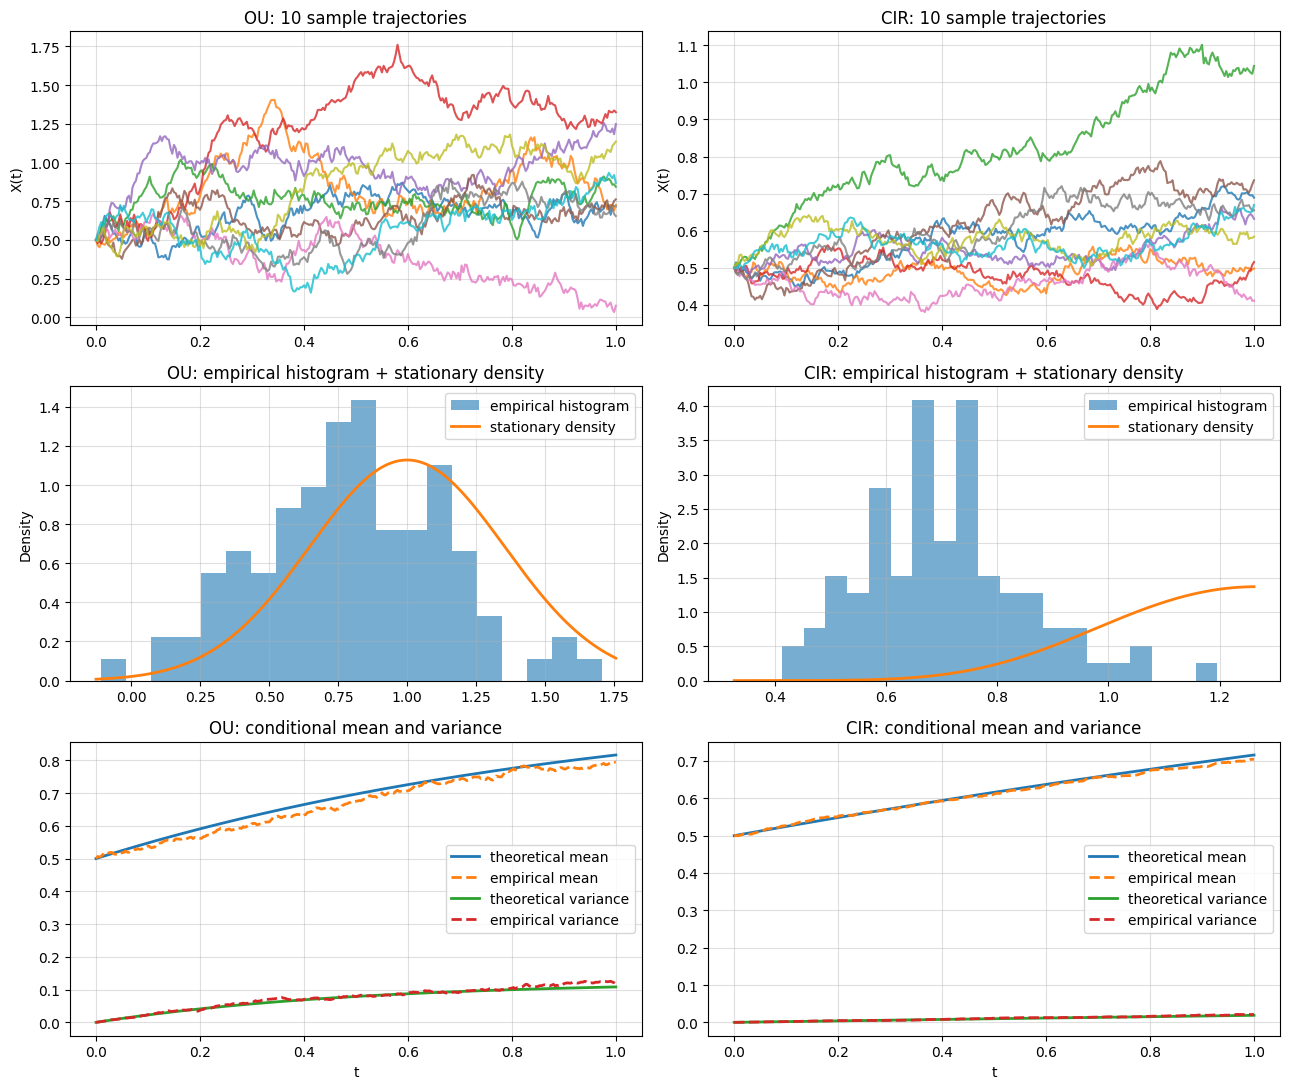

In [33]:
from scipy.stats import norm, gamma

# stationary distributions
ou_stationary_mean = mu_ou
ou_stationary_std = np.sqrt(sigma_ou**2 / (2 * theta_ou))

cir_shape = 2 * kappa_cir * theta_cir / sigma_cir**2
cir_scale = sigma_cir**2 / (2 * kappa_cir)

# plots (10 sample paths -> histogram -> conditional mean/var)
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

### plots for OU process
axes[0, 0].plot(t, ou_paths[:, :10], alpha=0.8)
axes[0, 0].set_title("OU: 10 sample trajectories")
axes[0, 0].set_ylabel("X(t)")
axes[0, 0].grid(True, alpha=0.4)

ou_emp = ou_paths[-1, :]
x_ou_grid = np.linspace(np.percentile(ou_emp, 1) - 0.2,
                        np.percentile(ou_emp, 99) + 0.2, 300)

axes[1, 0].hist(ou_emp, bins=20, density=True, alpha=0.6, label="empirical histogram")
axes[1, 0].plot(
    x_ou_grid,
    norm.pdf(x_ou_grid, loc=ou_stationary_mean, scale=ou_stationary_std),
    linewidth=2,
    label="stationary density"
)
axes[1, 0].set_title("OU: empirical histogram + stationary density")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.4)

axes[2, 0].plot(t, ou_mean_theory, label="theoretical mean", linewidth=2)
axes[2, 0].plot(t, ou_mean_emp, "--", label="empirical mean", linewidth=2)
axes[2, 0].plot(t, ou_var_theory, label="theoretical variance", linewidth=2)
axes[2, 0].plot(t, ou_var_emp, "--", label="empirical variance", linewidth=2)
axes[2, 0].set_title("OU: conditional mean and variance")
axes[2, 0].set_xlabel("t")
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.4)

### plots for CIR process
axes[0, 1].plot(t, cir_paths[:, :10], alpha=0.8)
axes[0, 1].set_title("CIR: 10 sample trajectories")
axes[0, 1].set_ylabel("X(t)")
axes[0, 1].grid(True, alpha=0.4)

cir_emp = cir_paths[-1, :]
x_cir_grid = np.linspace(max(0, np.percentile(cir_emp, 1) - 0.1),
                         np.percentile(cir_emp, 99) + 0.2, 300)

axes[1, 1].hist(cir_emp, bins=20, density=True, alpha=0.6, label="empirical histogram")
axes[1, 1].plot(
    x_cir_grid,
    gamma.pdf(x_cir_grid, a=cir_shape, scale=cir_scale),
    linewidth=2,
    label="stationary density"
)
axes[1, 1].set_title("CIR: empirical histogram + stationary density")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.4)

axes[2, 1].plot(t, cir_mean_theory, label="theoretical mean", linewidth=2)
axes[2, 1].plot(t, cir_mean_emp, "--", label="empirical mean", linewidth=2)
axes[2, 1].plot(t, cir_var_theory, label="theoretical variance", linewidth=2)
axes[2, 1].plot(t, cir_var_emp, "--", label="empirical variance", linewidth=2)
axes[2, 1].set_title("CIR: conditional mean and variance")
axes[2, 1].set_xlabel("t")
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [34]:
# comparison at different time points
time_points = [0.1, 0.5, 1.0]
rows = []

for tt in time_points:
    idx = int(round(tt / T * Nt))

    rows.append([
        "OU", tt,
        np.mean(ou_paths[idx]), ou_mean_theory[idx],
        np.var(ou_paths[idx], ddof=1), ou_var_theory[idx]
    ])

    rows.append([
        "CIR", tt,
        np.mean(cir_paths[idx]), cir_mean_theory[idx],
        np.var(cir_paths[idx], ddof=1), cir_var_theory[idx]
    ])

comparison_table = pd.DataFrame(
    rows,
    columns=[
        "Process",
        "t",
        "sample mean",
        "theoretical mean",
        "sample var",
        "theoretical var"
    ]
)

comparison_table

,Process,t,sample mean,theoretical mean,sample var,theoretical var
0,OU,0.1,0.538796,0.547581,0.023292,0.022659
1,CIR,0.1,0.527117,0.524629,0.002091,0.001990
2,OU,0.5,0.674839,0.696735,0.078060,0.079015
3,CIR,0.5,0.611402,0.616077,0.010975,0.009717
4,OU,1.0,0.794318,0.816060,0.116335,0.108083
5,CIR,1.0,0.704861,0.715985,0.021097,0.018772


#### Выводы

- **10 траекторий**: оба процесса имеют положительный дрейф к mu = 1, однако OU выходит стремительнее и шумнее из-за постоянной волатильности, в то время как у CIR она пропорциональна корню из X
- **Гистограммы конечных состояний и стационарные плотности:** процесс OU близко подошел к стационарному режиму, что видно было из траекторий, процесс CIR находится еще в переходном режиме
- **Условные средние и дисперсии:** эмпирические характеристики почти полностью совпадают с теоретическими значениями, однако есть небольшой сдвиг в сравнении средних у OU, что можно объяснить шумностью OU